# 01: A global fit in four lines

**This notebook targets the development stack (LATW `dev` branch).** It runs
the *installed* stock LISA global fit — the development versions of the
LISA Analysis Tools packages laid out by `LISAanalysistools/install.sh`,
not the pip releases. There is no Colab button; set the environment up
locally:

```bash
git clone https://github.com/lisa-analysis-tools/lisa-analysis-tools.git LISAanalysistools
bash LISAanalysistools/install.sh
```

For the pip-released workshop see the
[`main` branch](https://github.com/lisa-analysis-tools/LATW/tree/main).

In [1]:
import os

# Threading pinned to 1 everywhere (MPI-only policy; OMP-threaded kernels
# have OOM-killed laptops). See 06 for the backend/threading story.
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

# GF_NUM_ITER feeds num_iterations' default (an env-backed knob -- see the
# last section); two iterations are plenty to watch the whole pipeline turn
# over. A real run scales it to hundreds-plus.
os.environ.setdefault("GF_NUM_ITER", "2")
# The run can draw its own eryn diagnostic plots every few iterations
# (MAKE_PLOTS=1). We disable that and plot the reader arrays ourselves below,
# so a headless / LaTeX-free box never blocks on a plot-only step.
os.environ.setdefault("MAKE_PLOTS", "0")

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from copy import deepcopy
import dataclasses
from lisatools.utils.constants import *

# The run executed below is the *lightest* stock global fit -- gb_no_fg_lite
# (galactic binaries + a fixed instrument PSD). We turn a few knobs down on
# the shared lite default so the exact four-line bang stays fast and light on
# ANY machine (an 8 GB laptop included):
#   * num_iterations -> GF_NUM_ITER (the lite preset pins 10);
#   * a small 2x1 walker/temperature ensemble and a capped RJ leaf budget;
#   * in-process SYNTHETIC data, so the run never loads the multi-GB mojito
#     L1 files (the mojito default + its automatic synthetic fallback is the
#     last section).
from lisatools.globalfit.stock import erebor
erebor.gb_no_fg_lite.general.num_iterations = int(os.environ["GF_NUM_ITER"])
erebor.gb_no_fg_lite.general.data_mode = "synthetic"
erebor.gb_no_fg_lite.general.nwalkers = 2
erebor.gb_no_fg_lite.general.ntemps = 1
erebor.gb_no_fg_lite.gb.nleaves_max = 4      # cap the RJ leaf forest for speed

cupy not found, using numpy instead. This will be very slow for large runs. Please install cupy and a compatible CUDA version for GPU acceleration.


In this tutorial we run a LISA **global fit** end to end and then read every
product back out of it. The global fit is the joint Bayesian inference that
fits the resolvable sources (galactic binaries, massive-black-hole binaries,
EMRIs, stellar-origin BHBs) **and** the instrument-plus-confusion noise
**simultaneously**, sharing one data set and one residual. It is the endpoint
the rest of the workshop builds toward; this notebook is the fastest way to
see the whole machine move.

Every stock global fit is driven by the **same four-line pattern** — import
the family, pick a variant, `build()`, `run()` — so the *variant* you point
it at is the only thing that changes. The six-branch `all_sources` flagship
and the galactic-binaries-only `gb_no_fg` run through identical code. We
**document** the flagship and **execute** the lighter `gb_no_fg_lite`, so this
notebook turns over end to end on any machine (the flagship peaks near 4 GB —
see the next section).

We use a **stock configuration** — an installed, versioned run recipe
(`lisatools.globalfit.stock.erebor`) rather than a hand-edited settings file —
in its **lite** (laptop-smoke) form. Lite is the same machinery with every
knob turned down to a small CPU-friendly size; a production run scales the
identical object back up (last section).

### How to read this notebook

Every `##` section opens with a **TL;DR** and one minimal cell. Read the
section headers and TL;DRs for the surface; drop into the *"Going deeper"*
subsections when you are building your own pipeline. The
[`00`](00_SetupAndAtlas.ipynb) atlas places `lisatools.globalfit` in the
stack; the [`02`](02_StockGlobalFitGallery.ipynb) gallery surveys every
stock variant next, and [`08`](08_StockGlobalFitsInDepth.ipynb) opens the
stock machinery up.

## The four-line pattern

**TL;DR.** Import the stock family, pick a variant, `build()` it (the one
heavy step — data load + waveform + backend construction), and `run()`. Four
lines take you from nothing to a finished, on-disk global-fit run — and the
pattern is **identical for every stock variant**. Here is the flagship form
(the six-branch `all_sources`); we do *not* execute it here:

```python
from lisatools.globalfit.stock import erebor
fit = erebor.all_sources_lite()   # the full six-branch flagship
curr = fit.build()                # data load + all six waveforms + backend
fit.run()                         # hand off to the sampler
```

> **NOTE — running the flagship.** `all_sources` holds all six branches'
> waveforms plus one residual slab per walker in memory at once; even in lite
> form it peaks near **4 GB**, which OOM-kills an 8 GB laptop's notebook
> kernel mid-run. Launch it from a terminal instead, e.g.
> ```bash
> python scripts/run_global.py --stock all_sources_lite
> ```
> (see `LISAanalysistools/docs/global-fit-launch.md`), or run it on a bigger
> machine / GPU. **This notebook runs the SAME four-line pattern on the
> lighter `gb_no_fg_lite`** (galactic binaries + a fixed PSD, ~1.5 GB), so it
> executes anywhere. Everything below reads back out of *that* run;
> `all_sources` behaves identically, one branch set larger.

In [2]:
from lisatools.globalfit.stock import erebor
fit = erebor.gb_no_fg_lite()
curr = fit.build()
fit.run()

2026-07-13 03:32:39,876 - GeneralSetup - DEBUG - Saving h5 backend to ./gf_output_gb_no_fg/gb_no_fg_test_2_testing.h5


2026-07-13 03:32:39,876 - GeneralSetup - DEBUG - Saving artifacts to ./gf_output_gb_no_fg/gb_no_fg_test_2_artifacts/


2026-07-13 03:32:45,064 - GeneralSetup - INFO - Using fixed PSD kwargs: {'psd_params': [1.5e-11, 3e-15], 'galfor_params': None}


2026-07-13 03:32:45,072 - GeneralSetup - DEBUG - Preprocess setting: plot_folder = ./gf_output_gb_no_fg/gb_no_fg_test_2_artifacts/


2026-07-13 03:32:45,073 - GeneralSetup - DEBUG - Preprocess setting: highpass_kwargs = None


...

1it [00:06,  6.42s/it]

1it [00:06,  6.42s/it]


100%|██████████| 2/2 [00:06<00:00,  3.91s/it]

100%|██████████| 2/2 [00:06<00:00,  3.37s/it]

2026-07-13 03:33:02,804 - lisatools.globalfit.run - INFO - Residuals saved.


That is a complete run (2 sampler iterations here — we lowered the shared
lite default to `GF_NUM_ITER` in cell 3; lite's own default is 10).
`erebor.gb_no_fg_lite()` is the **galactic-binaries-only** stock fit: a single
reversible-jump `gb` branch over a fixed instrument PSD, in laptop-smoke form.
`build()` did the heavy lifting — it built the analysis data (here an
in-process synthetic GB stream, because we set `data_mode="synthetic"` in
cell 3; the mojito default + fallback is the last section), poured it onto a
WDM time–frequency grid, and constructed the GB waveform generator and the
HDF5 output backend. `run()` then handed the object to the sampler for
`GF_NUM_ITER` iterations.

`build()` returns the `curr` object — the built fit. Every product of the run
hangs off `curr`, and each of the sections below reads one surface of it back
out. The **flagship reads back the same way**: `all_sources` just has six
branches on `curr.branch_names` where this run has one.

> **This is a deliberately tiny, unconverged run** (2 iterations, 2 walkers,
> 1 temperature, a short 2-week WDM grid, a capped leaf budget). It exercises
> the pipeline; it does **not** produce a science posterior. A real run scales
> `num_iterations`, `nwalkers`, the grid, and the leaf counts up — the last
> section shows the one-line production twin.

## The samples: log-likelihood, chains, and RJ `inds`

**TL;DR.** `reader = curr.backend` is the run's eryn HDF5 backend. Its
`get_log_like()`, `get_chain()`, and `get_inds()` return the standard eryn
arrays — the log-likelihood trace, the per-branch parameter chains, and the
reversible-jump "which leaves are alive" mask.

In [3]:
reader = curr.backend
print("reader:", type(reader).__name__)

# log-like trace: (nsteps, ntemps, nwalkers)
print("log_like   :", reader.get_log_like().shape)

# chains: a dict keyed by branch name. Each is
# (nsteps, ntemps, nwalkers, nleaves_max, ndim).
chain = reader.get_chain()
print("branches   :", list(chain))
for name, arr in chain.items():
    print(f"  chain[{name!r}]".ljust(22), arr.shape)

# inds: the RJ leaf-occupation mask, (nsteps, ntemps, nwalkers, nleaves_max).
inds = reader.get_inds()
gb_alive = int(inds["gb"][-1, 0].sum())   # alive gb leaves, cold chain, last step
print("gb inds    :", inds["gb"].shape, "| alive now (cold chain):", gb_alive)

reader: GFHDFBackend
log_like   : (2, 1, 2)
branches   : ['gb']
  chain['gb']          (2, 1, 2, 4, 8)
gb inds    : (2, 1, 2, 4) | alive now (cold chain): 3


### Going deeper: the axes, temperatures, and the RJ leaf dimension

- **`nsteps`** is the number of recorded sampler iterations (here
  `GF_NUM_ITER`). **`ntemps`** is the parallel-tempering ladder; the **cold
  chain is index 0** and is the one you keep for the posterior
  (`chain[name][:, 0]`). **`nwalkers`** is the ensemble width.
- **`nleaves_max` + `ndim`** are the reversible-jump structure: each branch is
  a *forest* of up to `nleaves_max` sources ("leaves"), each an `ndim`-vector.
  The number of leaves is itself sampled, so `get_inds()` returns a boolean
  mask of which slots are currently occupied. `gb_no_fg` has one such RJ
  branch, `gb` (8 parameters per leaf). A **fixed-count** branch — like the
  `psd` / `galfor` noise branches the fuller fits add — simply has
  `nleaves_max = 1`, always alive. This is the branches/leaves/`inds`/`coords`
  picture from [`06` §Reversible-jump MCMC](06_ErynSmallToLarge.ipynb) — the
  global fit is that same sampler.
- Parameters are in each branch's **sampling basis** (not always the physical
  basis); the `transform` in the next section maps sampling → waveform
  parameters. Channels throughout are **XYZ** TDI.

## Per-branch source info

**TL;DR.** `curr.source_info[name]` is the built *Setup* for each branch — it
carries the sampled dimensionality, the analysis band, and the
sampling→waveform `transform`. Enumerate the branches with
`curr.branch_names` (here just `gb`; the flagship has six).

In [4]:
for name in curr.branch_names:
    si = curr.source_info[name]
    print(f"{name:7s} ndim={si.ndim}  nleaves_max={si.nleaves_max}")

print()
gb = curr.source_info["gb"]
print("gb band_edges (Hz) :", np.asarray(gb.band_edges))
print("gb transform       :", type(gb.transform).__name__)
print("gb signal_gen      :", gb.signal_gen)   # None: gb drives the residual from its own RJ move

gb      ndim=8  nleaves_max=4

gb band_edges (Hz) : [0.00736111 0.0075     0.00763889 0.00777778]
gb transform       : TransformContainer
gb signal_gen      : None


### Going deeper: what each field is for

- **`band_edges`** — the GB branch splits its frequency range into narrow
  sub-bands (the units the GB reversible-jump move works one at a time); the
  edges are snapped to WDM layer boundaries. Here the lite band is a single
  narrow window of a few sub-bands; the production `gb_no_fg` spans the whole
  6–25 mHz GB band.
- **`transform`** — an `eryn` `TransformContainer` mapping the *sampling*
  parameters (what the chains hold) to the *waveform* parameters (what the
  generator wants): e.g. `log`-amplitudes back to linear, chirp-mass +
  frequency to `fdot`, sky angles to the run frame. Forward and inverse are
  both available.
- **`signal_gen`** — a params → `DomainBase` generator. `gb` leaves it `None`
  and drives the residual from its dedicated reversible-jump move. The
  **source** branches the flagship adds — `mbh`, `emri`, `sobbh` — instead
  register a `signal_gen` so the engine builds and *subtracts* each leaf's
  template from the shared residual under the hood (`setup_acs`). That split
  is the subject of [`08` §5](08_StockGlobalFitsInDepth.ipynb) and
  [`02`](02_StockGlobalFitGallery.ipynb).

## The data that was fit

**TL;DR.** `curr.general_info.input_data_residual_array` is the analysis data
itself — a basis-tagged `DomainBase` signal (a `WDMSignal` here, because the
stock fit works in the WDM wavelet domain), shape `(nchannels, Nf, Nt)` in
XYZ.

data class : WDMSignal
data shape : (3, 137, 297)  (nchannels, Nf, Nt)
domain     : WDMSettings


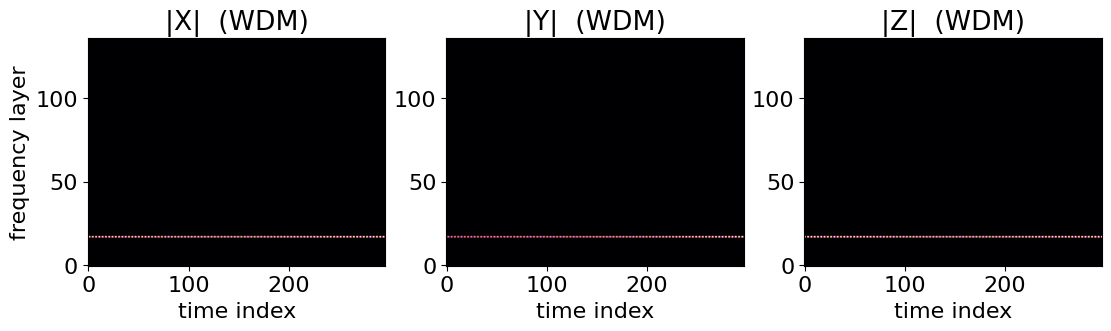

In [5]:
gi = curr.general_info
data = gi.input_data_residual_array
print("data class :", type(data).__name__)
print("data shape :", data.shape, " (nchannels, Nf, Nt)")
print("domain     :", type(gi.domain_settings).__name__)

arr = np.abs(np.asarray(data.arr))     # |WDM coefficients|, XYZ
fig, axes = plt.subplots(1, arr.shape[0], figsize=(11, 3.2), constrained_layout=True)
for ch, ax in zip("XYZ", np.atleast_1d(axes)):
    i = "XYZ".index(ch)
    ax.imshow(arr[i], aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"|{ch}|  (WDM)")
    ax.set_xlabel("time index")
axes[0].set_ylabel("frequency layer")
plt.show()

### Going deeper: the WDM data and the residual

The stock global fit lives in the **WDM (Wilson–Daubechies–Meyer) wavelet
domain** — a time–frequency tiling that is sparse for the slowly-evolving
galactic binaries that dominate the LISA band (see
[`03` §Domains](03_Foundations.ipynb)). `input_data_residual_array` is the
*data* the fit was handed; during sampling the engine keeps a **residual** =
data − (all currently-subtracted templates) inside an `AnalysisContainerArray`,
one slab per walker, and every move scores its proposals against that
residual. `data.arr` is the raw coefficient array; `data` also knows how to
transform itself to other bases (`.fft()`, …) and to plot itself.

## Diagnostic plots

**TL;DR.** `lisatools.globalfit.diagnosticplot` holds the run's plot
producers — `plot_loglikelihood`, `produce_mbh_plots`, `produce_psd_plots`, …
— plus the `DiagnosticPlotter` sampler callback the run fires every
`plot_iterations` steps when `MAKE_PLOTS=1`. They read straight from a
`reader`.

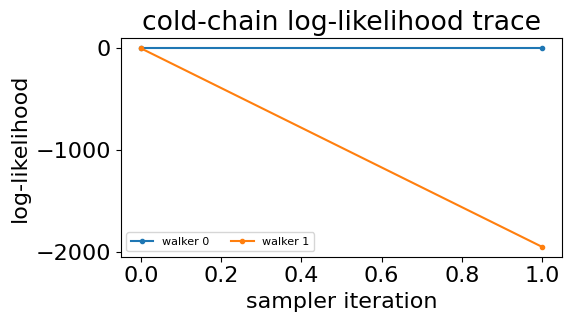

packaged producers: ['plot_loglikelihood', 'produce_emri_plots', 'produce_galfor_plots', 'produce_gb_plots', 'produce_mbh_plots', 'produce_psd_plots']


In [6]:
from lisatools.globalfit import diagnosticplot

# The packaged producers (plot_loglikelihood / produce_*_plots) and the
# DiagnosticPlotter callback render in a publication LaTeX style
# (text.usetex=True), so *calling* them needs a LaTeX install. The numbers
# they draw are just reader arrays, so on a bare box we plot them directly:
logl = reader.get_log_like()[:, 0]          # cold chain, (nsteps, nwalkers)
plt.figure(figsize=(6, 3.5))
for w in range(logl.shape[1]):
    plt.plot(logl[:, w], marker=".", label=f"walker {w}")
plt.xlabel("sampler iteration"); plt.ylabel(r"log-likelihood")
plt.title("cold-chain log-likelihood trace")
plt.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

print("packaged producers:", [n for n in dir(diagnosticplot)
                              if n.startswith(("plot_", "produce_"))])

### Going deeper: wiring the packaged plotters into a run

`DiagnosticPlotter(curr, plot_every=...)` is a callback: pass it to the
sampler and it writes per-branch trace + corner PNGs and the log-likelihood
evolution into the run's `…_artifacts/diagnostic_plots/` folder every few
iterations. The stock run installs it automatically when
`make_diagnostic_plots` is on (env `MAKE_PLOTS=1`, cadence `PLOT_ITERATIONS`).
With a LaTeX toolchain present you can also call the producers directly, e.g.
`diagnosticplot.produce_psd_plots(reader=reader, save_dir="./")`. The
postprocessing / catalogue side lives in
`lisatools.globalfit.postprocessing`.

## The run on disk

**TL;DR.** Everything is persisted under `curr.general_info.file_store_dir`:
the primary HDF5 backend (the chains `reader` reads), plus an `…_artifacts/`
folder with the run log, a human-readable settings dump, and any diagnostic
plots.

In [7]:
import glob
fsd = gi.file_store_dir
print("file_store_dir:", fsd)
print("main HDF5      :", gi.main_file_path)
print()
for p in sorted(glob.glob(os.path.join(fsd, "**"), recursive=True)):
    if os.path.isfile(p):
        print(f"  {os.path.relpath(p, fsd):55s} {os.path.getsize(p):>10,d} B")

file_store_dir: ./gf_output_gb_no_fg/
main HDF5      : ./gf_output_gb_no_fg/gb_no_fg_test_2_testing.h5

  gb_no_fg_test_2_artifacts/general_setup.log                 13,910 B
  gb_no_fg_test_2_artifacts/global_fit.log                       257 B
  gb_no_fg_test_2_artifacts/globalfit_run.log                  4,650 B
  gb_no_fg_test_2_artifacts/run_settings.log                   4,469 B
  gb_no_fg_test_2_artifacts/wdm_data.png                      17,993 B
  gb_no_fg_test_2_testing.h5                                 103,554 B
  gb_setup.log                                                   341 B


### Going deeper: the layout

- **`<base>_<main_file_key>.h5`** — the eryn HDF5 backend: log-like,
  per-branch chains, `inds`, betas, acceptance. `reader = curr.backend` points
  at exactly this file; you can reopen it later with `GFHDFBackend(path)` and
  re-read without re-running.
- **`<base>_artifacts/`** — `globalfit_run.log` (the full run log),
  `run_settings.log` (the `dump_settings` summary, see the next section),
  `general_setup.log`, and `diagnostic_plots/` when plotting is on.

`file_store_dir` / `base_file_name` / `main_file_key` are all knobs (env
`FILE_STORE_DIR` / `BASE_FILE_NAME`), so separate runs never collide.

## Every knob, before `build()`

**TL;DR.** A stock fit is a cheap, fully-inspectable *configuration* until you
call `build()`. Before building you can read and edit **every** knob: the
general block (`fit.general` + its dataclass fields), each branch block
(`fit.gb`, …), and the recipe (`fit.recipe`). Nothing heavy has happened yet,
so editing is instant and free — this is exactly what you do *"as if you
wanted to adjust settings before `fit.build()`"*.

In [8]:
fit2 = erebor.gb_no_fg_lite()      # a fresh, unbuilt clone
print(type(fit2).__name__, "| built?", fit2.built)

GBNoForegroundLiteGlobalFit | built? False


`fit2.describe()` is the one-glance summary — headline knobs, branch
list, and the recipe:

In [9]:
print(fit2.describe())

GBNoForegroundLiteGlobalFit (gb_no_fg_lite) — Laptop-smoke twin of gb_no_fg: two-week span, 10 iterations, 4 walkers x 2 temps, 2 GB repeat proposals, CPU.
  built: False
  headline:
    nwalkers = 2
    ntemps = 1
    dt = 2.5
    num_iterations = 2
    file_store_dir = './gf_output_gb_no_fg/'
    base_file_name = 'gb_no_fg_test_2'
    gpus = None
    gpu_backend = 'auto'
    tobs_target = 1209600.0
    min_freq = 0.006
    max_freq = 0.025
    tdi_chan = 'XYZ'
    window_tukey_alpha = 0.05
    mojito_data_path = '/Users/mkatz/.mojito_cache/brickmarket/mojito_light_v1_0_0/'
    use_gpu = False
  branches: ['gb']
    gb: GBNoFgGBSettings
  recipe:
    [pe] gb_pe:
        rj_prior  <- stock branch=gb
  setup_function: setup_recipe


**The general block.** `fit.general` is a dataclass; every field is a
documented knob. The headline ones (`nwalkers`, `num_iterations`, `dt`,
`tobs_target`, `tdi_chan`, …) are also settable straight on the fit
(`fit.nwalkers = 8`) and delegate down to `fit.general`. Here is the full
field surface:

In [10]:
gen = fit2.general
print(type(gen).__name__, "fields:\n")
for f in dataclasses.fields(gen):
    print(f"  {f.name:24s} = {repr(getattr(gen, f.name))[:52]}")

GBNoFgGeneralSettings fields:

  Tobs                     = None
  dt                       = 2.5
  initialize_kwargs        = None
  transform                = None
  priors                   = None
  periodic                 = None
  nleaves_max              = None
  nleaves_min              = None
  ndim                     = None
  betas                    = None
  other_tempering_kwargs   = None
  branch_state             = None
  branch_backend           = None
  log_dir                  = None
  signal_gen               = None
  num_iterations           = 2
  file_store_dir           = './gf_output_gb_no_fg/'
  base_file_name           = 'gb_no_fg_test_2'
  main_file_key            = 'testing'
  past_file_for_start      = None
  orbits                   = None
  gpu_orbits               = None
  domain_settings          = None
  random_seed              = 103209
  backup_iter              = 5
  hdf_compression          = 'gzip'
  hdf_compression_opts     = 4
  nwalkers          

**The branch blocks.** One dataclass per branch, addressed by name.
`gb_no_fg` carries a single `gb` branch; the flagship carries six. Same story
either way — read or assign any field before building:

In [11]:
for name in fit2.branches:
    blk = getattr(fit2, name)
    print(f"{name:7s} -> {type(blk).__name__}")

# a full dump of one branch block
print("\nfit2.gb as a dict (dataclasses.asdict):")
gb_dict = dataclasses.asdict(fit2.gb)
for k in ("ndim", "nleaves_min", "nleaves_max", "min_freq", "max_freq",
          "num_repeat_proposals", "mode", "start"):
    print(f"  {k:22s} = {gb_dict[k]!r}")

gb      -> GBNoFgGBSettings

fit2.gb as a dict (dataclasses.asdict):
  ndim                   = 8
  nleaves_min            = 0
  nleaves_max            = 4
  min_freq               = 0.00736
  max_freq               = 0.00778
  num_repeat_proposals   = 2
  mode                   = 'pe'
  start                  = 'truth'


**The recipe.** `fit.recipe` is the ordered stack of sampler moves.
`fit.list_moves()` prints it; `fit.recipe` supports `add_move` / `pop_move` /
`add_stage` / `pop_stage` for editing it before the build (the deep dive is
[`08` §Recipes](08_StockGlobalFitsInDepth.ipynb)).

In [12]:
print(fit2.recipe, "\n")
print(fit2.list_moves())

RecipeSpec(['gb_pe']) 

[pe] gb_pe:
    rj_prior  <- stock branch=gb


**Dumping the settings.** `dataclasses.asdict` serializes any single block;
`lisatools.globalfit.loginfo.dump_settings` writes a full human-readable
summary of a *built* fit's settings (general + every branch + rank info) — the
same `run_settings.log` the run drops in its artifacts folder.

In [13]:
from lisatools.globalfit.loginfo import dump_settings
dump_settings(curr.settings_dict, gi.artifacts_file_dir)
with open(os.path.join(gi.artifacts_file_dir, "run_settings.log")) as f:
    print("".join(f.readlines()[:22]))

GLOBAL FIT RUN SETTINGS

----------------------------------------
GENERAL SETTINGS
----------------------------------------
  Tobs: np.float64(1209600.0)
  dt: 2.5
  initialize_kwargs: None
  transform: None
  priors: None
  periodic: None
  nleaves_max: None
  nleaves_min: None
  ndim: None
  betas: None
  other_tempering_kwargs: None
  branch_state: None
  branch_backend: None
  log_dir: None
  signal_gen: None



### A worked edit: change a knob before building

Everything above is read-only inspection. Now actually *change* something.
Editing a stock fit is plain attribute assignment on a live Python object —
no settings file to fork. We free the first run first (it holds the big
per-walker residual array), then bump a GB proposal knob on a fresh
`gb_no_fg_lite` and build+run the edited fit. Because a second build in the
same kernel needs its own HDF5 backend, we give it a **distinct**
`base_file_name` (eryn will not reuse one run's backend for another).

In [14]:
# The heavy object is the built run's per-walker residual array, held by
# `curr`; free it before the second build so peak RAM stays low. We keep the
# lightweight `gi` GeneralSetup for the last cell.
import gc
del fit, curr, reader, data
gc.collect()

# Editing before build is just attribute assignment on a live object. A
# DISTINCT base_file_name keeps this run's HDF5 backend off the first one's.
fit_edit = erebor.gb_no_fg_lite(base_file_name="quickstart_edit")
print("gb num_repeats (lite default):", fit_edit.gb.num_repeat_proposals)

fit_edit.gb.num_repeat_proposals = 4        # <- the one edit
print("gb num_repeats (after edit)  :", fit_edit.gb.num_repeat_proposals)
print()

# ...and then it is the SAME four lines as the top -- build + run:
curr_edit = fit_edit.build()
fit_edit.run()
print("\nedited run finished; final cold-chain logL:",
      np.round(curr_edit.backend.get_log_like()[-1, 0], 3))

gb num_repeats (lite default):

2
gb num_repeats (after edit)  : 4

2026-07-13 03:33:04,590 - GeneralSetup - DEBUG - Saving h5 backend to ./gf_output_gb_no_fg/quickstart_edit_testing.h5


2026-07-13 03:33:04,591 - GeneralSetup - DEBUG - Saving artifacts to ./gf_output_gb_no_fg/quickstart_edit_artifacts/


2026-07-13 03:33:10,052 - GeneralSetup - INFO - Using fixed PSD kwargs: {'psd_params': [1.5e-11, 3e-15], 'galfor_params': None}


2026-07-13 03:33:10,059 - GeneralSetup - DEBUG - Preprocess setting: plot_folder = ./gf_output_gb_no_fg/quickstart_edit_artifacts/


...

1it [00:06,  6.48s/it]


100%|██████████| 2/2 [00:06<00:00,  3.93s/it]

100%|██████████| 2/2 [00:06<00:00,  3.38s/it]

2026-07-13 03:33:27,010 - lisatools.globalfit.run - INFO - Residuals saved.



edited run finished; final cold-chain logL: [   -6.393 -1947.819]


The edit landed and the edited fit built and ran — a changed GB knob by plain
attribute assignment, no settings file touched. The same verbs compose
*branches* in and out (`fit.remove_branch(...)`, `fit.add_branch(...)`) and
*moves* in and out (`fit.pop_move`, `fit.recipe.add_move`) before the build —
the deep dive is [`08`](08_StockGlobalFitsInDepth.ipynb). That editability is
the whole point of the stock layer: the configuration is code you change, not
a file you fork.

## Going deeper: singletons, lite ↔ heavy, and env knobs

### Singleton default vs. clone

`erebor.gb_no_fg_lite` (no parentheses) is a **module-level singleton** — one
shared default instance living in memory. **Calling** it,
`erebor.gb_no_fg_lite()`, returns a fresh **deepcopy clone** with the
overrides applied, leaving the singleton untouched. That is why every section
above started from its own `erebor.gb_no_fg_lite()`. (Mutating the singleton
*in place* — `erebor.gb_no_fg_lite.nwalkers = 8`, as cell 3 did — changes the
session-wide default for later clones; deliberate, but shared.)

In [15]:
base = erebor.gb_no_fg_lite            # the singleton
clone = erebor.gb_no_fg_lite()         # a fresh clone
print("same object?", clone is base, "| same class:", type(clone) is type(base))
print("clone with an override:", erebor.gb_no_fg_lite(nwalkers=8).general.nwalkers)

same object? False | same class: True
clone with an override: 8


### Lite ↔ heavy, both directions

`gb_no_fg_lite` is the laptop-smoke twin of the production `gb_no_fg`; lite
just turns a stack of knobs down. Three ways reach the same lite
configuration, and the production twin is one call away:

```python
fit = erebor.gb_no_fg_lite()       # the registered lite twin (what this notebook ran)
fit = erebor.gb_no_fg(lite=True)   # the production model with the lite preset applied
fit = erebor.gb_no_fg()            # the production configuration (full band, GF_NUM_ITER)
```

The lite preset changes only turned-down knobs — scale any of them back up to
move toward production, or start from `erebor.gb_no_fg()` and turn individual
knobs *down*:

| knob | lite (`gb_no_fg_lite`) | production (`gb_no_fg`) |
|---|---|---|
| `general.num_iterations` | 10 | hundreds (`GF_NUM_ITER`) |
| `general.nwalkers` × `ntemps` | 4 × 2 | catalogue-scale |
| `general.tobs_target` | two weeks | full mission span |
| GB band (`min_freq`–`max_freq`) | one narrow ~7.4 mHz window | 6–25 mHz (full) |
| `gb.num_repeat_proposals` | 2 | 100 |
| `general.use_gpu` | `False` (CPU) | auto-detect |

**`all_sources` works exactly the same way** (`erebor.all_sources()` /
`all_sources(lite=True)` / `all_sources_lite()`), as does every stock variant.
`erebor.get_stock_options()` lists them all (each full model has a `*_lite`
twin):

In [16]:
for name, desc in erebor.get_stock_options():
    print(f"  {name:24s} {desc[:60]}")

  gb_no_fg                 GB-only fit on the mojito L1 GB galaxy: fixed PSD, no foregr
  all_sources              All six branches (gb, psd, galfor, mbh, emri, sobbh) compose
  full_year_combined       Catalogue-driven multi-leaf MBH+EMRI+SOBBH fit over the full
  noise_only               Joint WDM noise fit: instrument PSD + hyperbolic-tangent gal
  noise_sgwb               Joint WDM noise fit: instrument PSD + galactic foreground + 
  gb_no_fg_lite            Laptop-smoke twin of gb_no_fg: two-week span, 10 iterations,
  all_sources_lite         Laptop-smoke twin of all_sources: the same six branches and 
  full_year_combined_lite  Laptop-smoke twin of full_year_combined: one month instead o
  noise_only_lite          Laptop-smoke twin of noise_only: quarter-length time grid, 1
  noise_sgwb_lite          Laptop-smoke twin of noise_sgwb: quarter-length time grid, 1


### Env knobs and precedence

Many defaults are **environment-backed**, resolving in this order:

> **explicit kwarg  >  lite preset  >  environment variable  >  hard default**

So `fit_edit.gb.num_repeat_proposals = 4` above (an explicit assignment) wins
over everything, and the `*_lite` preset's turned-down knobs win over env
vars. The common env knobs: `GF_NUM_ITER` (iterations), `NWALKERS` / `NTEMPS`,
`DATA_PROCESSOR` (data mode), `USE_GPU` / `GPUS` / `GPU_BACKEND`,
`TOBS_TARGET`, `FILE_STORE_DIR`. [`08` §3](08_StockGlobalFitsInDepth.ipynb)
covers the resolution machinery.

### The mojito → synthetic fallback

`gb_no_fg` defaults to mojito L1 data (`data_mode="mojito"`). When the mojito
folder is absent on a machine, `build()` **falls back to `"synthetic"`**
automatically — it builds the GB data stream *in-process* with injection
coordinates drawn from the source priors, so
`erebor.gb_no_fg_lite(); fit.build(); fit.run()` works on a bare laptop with
no external data at all. Set `data_mode` (or `DATA_PROCESSOR`) explicitly, or
supply your own injections, to override — which is exactly what this notebook
did in cell 3 (`...data_mode = "synthetic"`) so it runs identically with or
without mojito data on hand. The data layer is the subject of
[`08` §2](08_StockGlobalFitsInDepth.ipynb).

In [17]:
print("this run's data_mode:", gi.data_mode)   # gi = the gb_no_fg run's GeneralSetup

this run's data_mode: synthetic


## Where to go next

- [`02`](02_StockGlobalFitGallery.ipynb) — the stock global-fit **gallery**:
  a run-it catalogue of every stock variant (`gb_no_fg`, `noise_only`,
  `noise_sgwb`, `full_year_combined`, and the six-branch `all_sources`
  flagship), surveyed right after this quickstart.
- [`03`–`08`](03_Foundations.ipynb) — the details, one layer at a time: the
  foundations (domains & sensitivity & the `AnalysisContainer`), the response
  & TDI, the source waveforms, sampling with Eryn, the backends, and the stock
  global-fit machinery in depth ([`08`](08_StockGlobalFitsInDepth.ipynb): the
  data layer, the settings pyramid, recipes, and **writing your own move
  module**).
- [`further/`](further/) — the exercises, once you want to build your own
  analyses.